In [86]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [87]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print(df.head())

print("\nShape:", df.shape)

print("\nInfo:")
df.info()

print("\nNull Values:")
print(df.isnull().sum())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

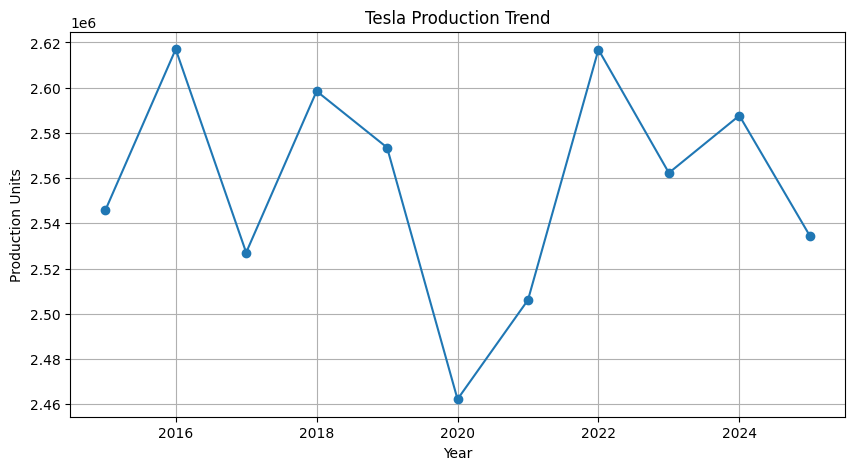

In [88]:
# production trend 
import matplotlib.pyplot as plt
yearly_production = df.groupby('Year')['Production_Units'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_production.index, yearly_production.values, marker='o')
plt.title("Tesla Production Trend")
plt.xlabel("Year")
plt.ylabel("Production Units")
plt.grid(True)
plt.show()

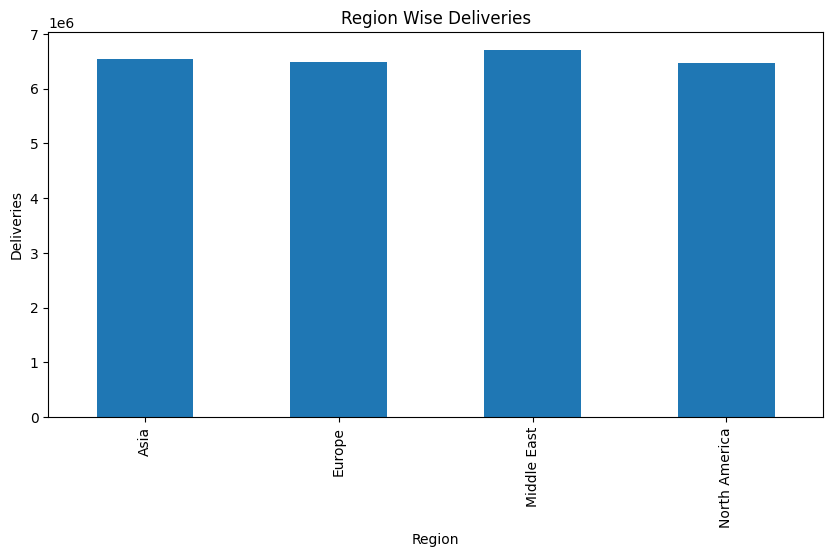

In [89]:
#Region Wise Deliveries
plt.figure(figsize=(10,5))

df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar')

plt.title("Region Wise Deliveries")
plt.ylabel("Deliveries")
plt.show()

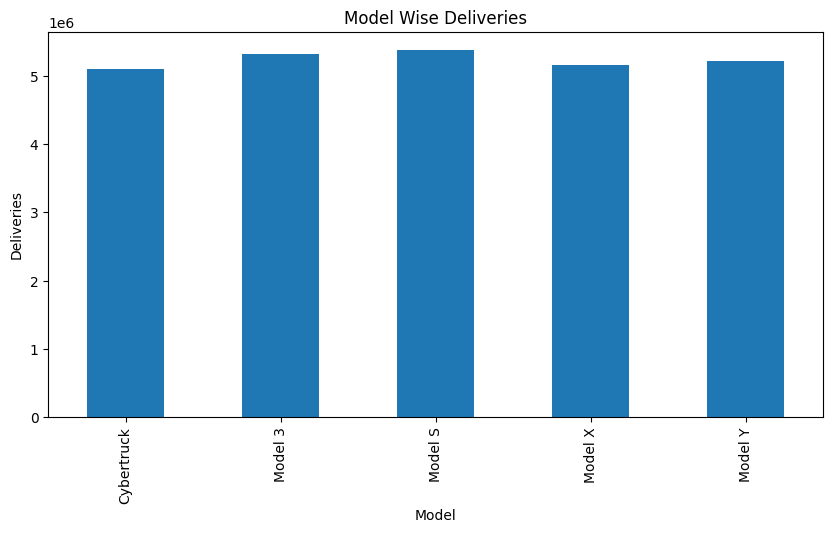

In [90]:
#Model Wise Deliveries
plt.figure(figsize=(10,5))

df.groupby('Model')['Estimated_Deliveries'].sum().plot(kind='bar')

plt.title("Model Wise Deliveries")
plt.ylabel("Deliveries")
plt.show()

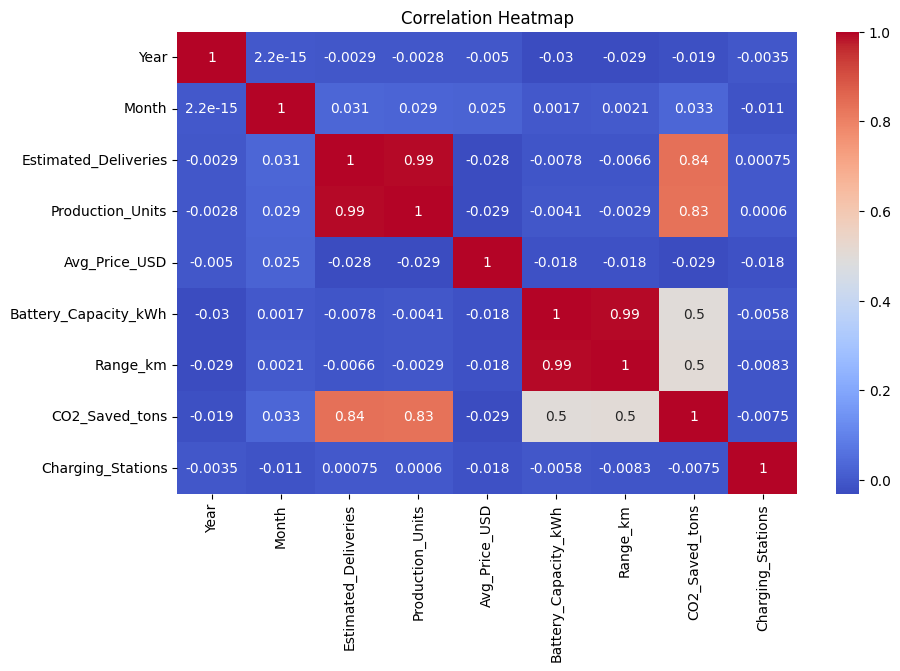

In [91]:
#Correlation Heatmap
import seaborn as sns
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [92]:
#Feature Engineering
from sklearn.preprocessing import LabelEncoder

print("Sklearn imported successfully")


Sklearn imported successfully


In [93]:
le_region = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])

print(df[['Region']].head())

   Region
0       1
1       0
2       3
3       3
4       2


In [94]:
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

print(X.shape)
print(y.shape)

(2640, 11)
(2640,)


In [95]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 11)
(528, 11)


In [96]:
#. Linear Regression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Encode categorical columns
df['Region'] = LabelEncoder().fit_transform(df['Region'])
df['Model'] = LabelEncoder().fit_transform(df['Model'])
df['Source_Type'] = LabelEncoder().fit_transform(df['Source_Type'])

# Features and Target
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Results")
print("R2 Score:", r2_score(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

Linear Regression Results
R2 Score: 0.9901296027802067
RMSE: 383.5765698703907


In [97]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("R2 Score:", r2_score(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

Random Forest Results
R2 Score: 0.9887505867840798
RMSE: 409.4960252956731


In [98]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}


In [99]:
#Best Model Evaluation
best_model = grid.best_estimator_

pred_best = best_model.predict(X_test)

print("Tuned Random Forest")
print("R2 Score:", r2_score(y_test, pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_best)))

Tuned Random Forest
R2 Score: 0.9887505867840798
RMSE: 409.4960252956731


In [100]:
#Create Date Column
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

print(df[['Date']].head())

        Date
0 2023-05-01
1 2015-02-01
2 2019-01-01
3 2021-02-01
4 2016-12-01


In [101]:
#Aggregate Monthly Deliveries
ts = df.groupby('Date')['Estimated_Deliveries'].sum()

print(ts.head())

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64


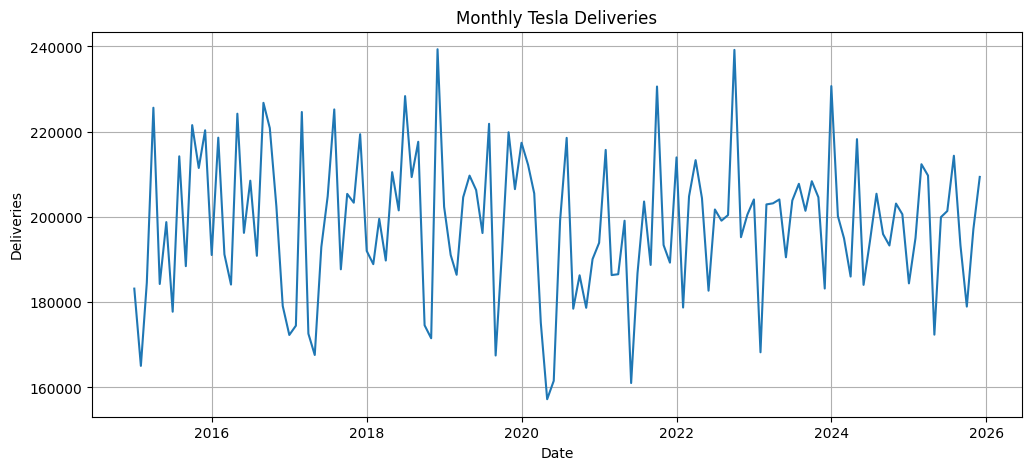

In [102]:
#Plot Time Series
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts)

plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.grid(True)

plt.show()

In [103]:
#ARIMA Forecast
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts, order=(5,1,0))

model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

print(forecast)

2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


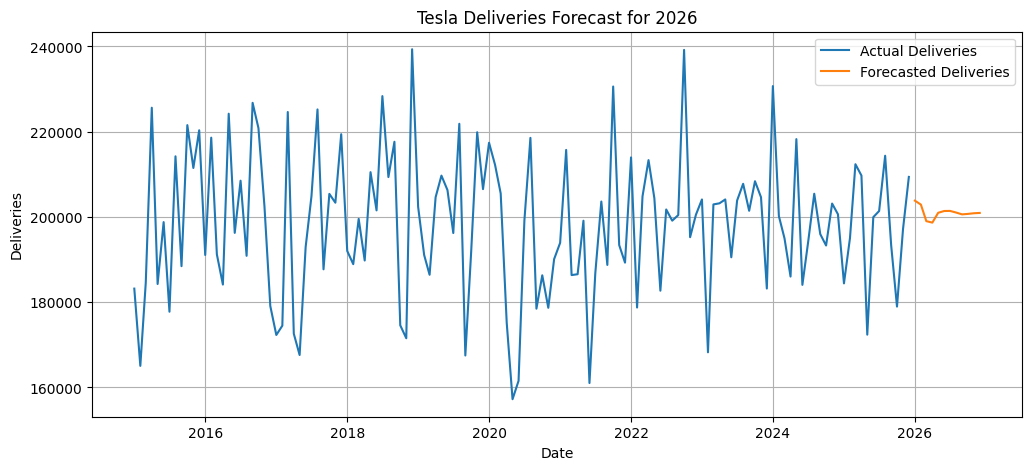

In [104]:
#Forecast Plot
future_dates = pd.date_range(
    start=ts.index[-1],
    periods=13,
    freq='MS'
)[1:]

plt.figure(figsize=(12,5))

plt.plot(ts, label='Actual Deliveries')

plt.plot(
    future_dates,
    forecast,
    label='Forecasted Deliveries'
)

plt.title("Tesla Deliveries Forecast for 2026")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Conclusion

In this assignment, Tesla's delivery and production data from 2015 to 2025 was analyzed using machine learning techniques.

Data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting were performed.

The analysis showed that Tesla deliveries have grown significantly over the years. Among the regression models, Linear Regression achieved the best performance with high prediction accuracy.

The forecasting results indicate that Tesla deliveries are expected to remain strong in the coming months.

Overall, this assignment provided useful insights into Tesla's growth, production trends, and future delivery predictions.